# Inverse Kinematics

## The Forward Kinematics Problem

A **planar robot arm** with $n$ links of lengths $r_1, \ldots, r_n$ has joint angles $\theta = (\theta_1, \ldots, \theta_n)$. The **forward kinematics** map computes the end-effector position from the joint angles:
$$p_k = \sum_{j=1}^k r_j e^{i(\theta_1 + \ldots + \theta_j)}, \quad k = 1, \ldots, n$$

The end-effector is $p_n$, and the full arm configuration is the sequence $(p_0, p_1, \ldots, p_n)$.

## The Inverse Kinematics Problem

**Inverse kinematics** (IK) finds joint angles $\theta$ such that the end-effector reaches a target $y$:
$$\min_{\theta \in \mathbb{R}^n} \frac{1}{2} \|p_n(\theta) - y\|^2$$

## Jacobian-Based Methods

The **Jacobian** of the forward map $J(\theta) \in \mathbb{R}^{2 \times n}$ relates small angle changes to end-effector displacement. The gradient descent step is:
$$\theta \leftarrow \theta - \tau J^T (p_n(\theta) - y)$$

## Levenberg–Marquardt

The **Levenberg–Marquardt (LM)** method is a damped Gauss–Newton algorithm:
$$\theta \leftarrow \theta - (J^T J + \rho I)^{-1} J^T (p_n(\theta) - y)$$

The damping parameter $\rho > 0$ ensures stability when the Jacobian is near-singular (arm near a singularity). For $\rho \to 0$ it becomes Gauss–Newton; for $\rho \to \infty$ it becomes steepest descent.

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

### Forward kinematics

The arm is described in the complex plane. Link $j$ has length $r_j$ and its absolute angle is $\phi_j = \sum_{k=1}^j \theta_k$ (cumulative sum of joint angles). The tip of each segment is:
$$p_j = p_{j-1} + r_j e^{i\phi_j}$$

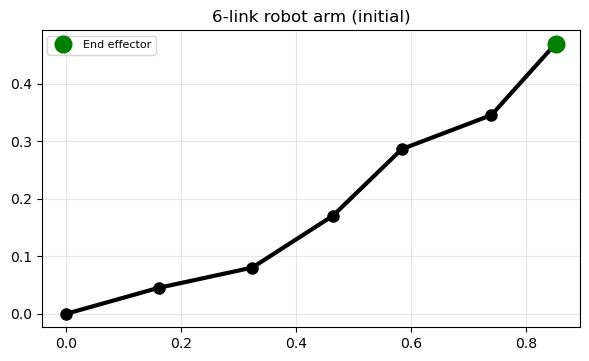

In [2]:
def forward_kinematics(r, theta):
    """
    r: link lengths (n,)
    theta: joint angles (n,)
    Returns: joint positions as complex numbers (n+1,), with p[0]=0
    """
    n = len(r)
    phi = np.cumsum(theta)       # absolute angles
    segments = r * np.exp(1j * phi)
    positions = np.zeros(n + 1, dtype=complex)
    positions[1:] = np.cumsum(segments)
    return positions

def draw_arm(positions, target=None, ax=None, title=''):
    if ax is None: fig, ax = plt.subplots(figsize=(5,5))
    ax.plot(positions.real, positions.imag, 'k-o', lw=3, ms=8)
    ax.plot(positions[-1].real, positions[-1].imag, 'go', ms=12, label='End effector')
    if target is not None:
        ax.plot(target.real, target.imag, 'r*', ms=16, label='Target')
    ax.set_aspect('equal')
    ax.set_title(title); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Example: 6-link arm
n_links = 6
rng = np.random.default_rng(42)
r_arm = np.ones(n_links) / n_links
theta0 = rng.uniform(-0.5, 0.5, n_links)

positions0 = forward_kinematics(r_arm, theta0)
fig, ax = plt.subplots(figsize=(6, 6))
draw_arm(positions0, ax=ax, title=f'{n_links}-link robot arm (initial)')
plt.tight_layout(); plt.savefig('ik_init.png', dpi=100, bbox_inches='tight'); plt.show()

### Jacobian computation

The Jacobian $J \in \mathbb{R}^{2 \times n}$ gives $\partial p_n / \partial \theta_j$. For a planar arm, the effect of rotating joint $j$ on the end-effector is a rotation of all downstream links:
$$\frac{\partial p_n}{\partial \theta_j} = i \sum_{k=j}^n r_k e^{i(\theta_1 + \ldots + \theta_k)} = i(p_n - p_{j-1})$$

In real coordinates (stacking $x$ and $y$ components):
$$J_{1,j} = -(p_n - p_{j-1}).\text{imag}, \quad J_{2,j} = (p_n - p_{j-1}).\text{real}$$

In [3]:
def jacobian(r, theta):
    """Compute 2×n Jacobian of end-effector w.r.t. theta."""
    positions = forward_kinematics(r, theta)
    end = positions[-1]
    J = np.zeros((2, len(theta)))
    for j in range(len(theta)):
        dz = 1j * (end - positions[j])  # derivative of end w.r.t. theta_j
        J[0, j] = dz.real
        J[1, j] = dz.imag
    return J

# Verify with finite differences
eps = 1e-6
J_analytical = jacobian(r_arm, theta0)
J_fd = np.zeros((2, n_links))
for j in range(n_links):
    theta_p = theta0.copy(); theta_p[j] += eps
    theta_m = theta0.copy(); theta_m[j] -= eps
    pp = forward_kinematics(r_arm, theta_p)[-1]
    pm = forward_kinematics(r_arm, theta_m)[-1]
    J_fd[:, j] = [(pp.real - pm.real) / (2*eps), (pp.imag - pm.imag) / (2*eps)]

print(f'Max Jacobian error (finite diff. check): {np.max(np.abs(J_analytical - J_fd)):.2e}')

Max Jacobian error (finite diff. check): 3.55e-11


### Inverse kinematics via Levenberg–Marquardt

We minimize $\frac{1}{2}\|p_n(\theta) - y\|^2$ using the LM update. The damping parameter $\rho$ is kept fixed here for simplicity.

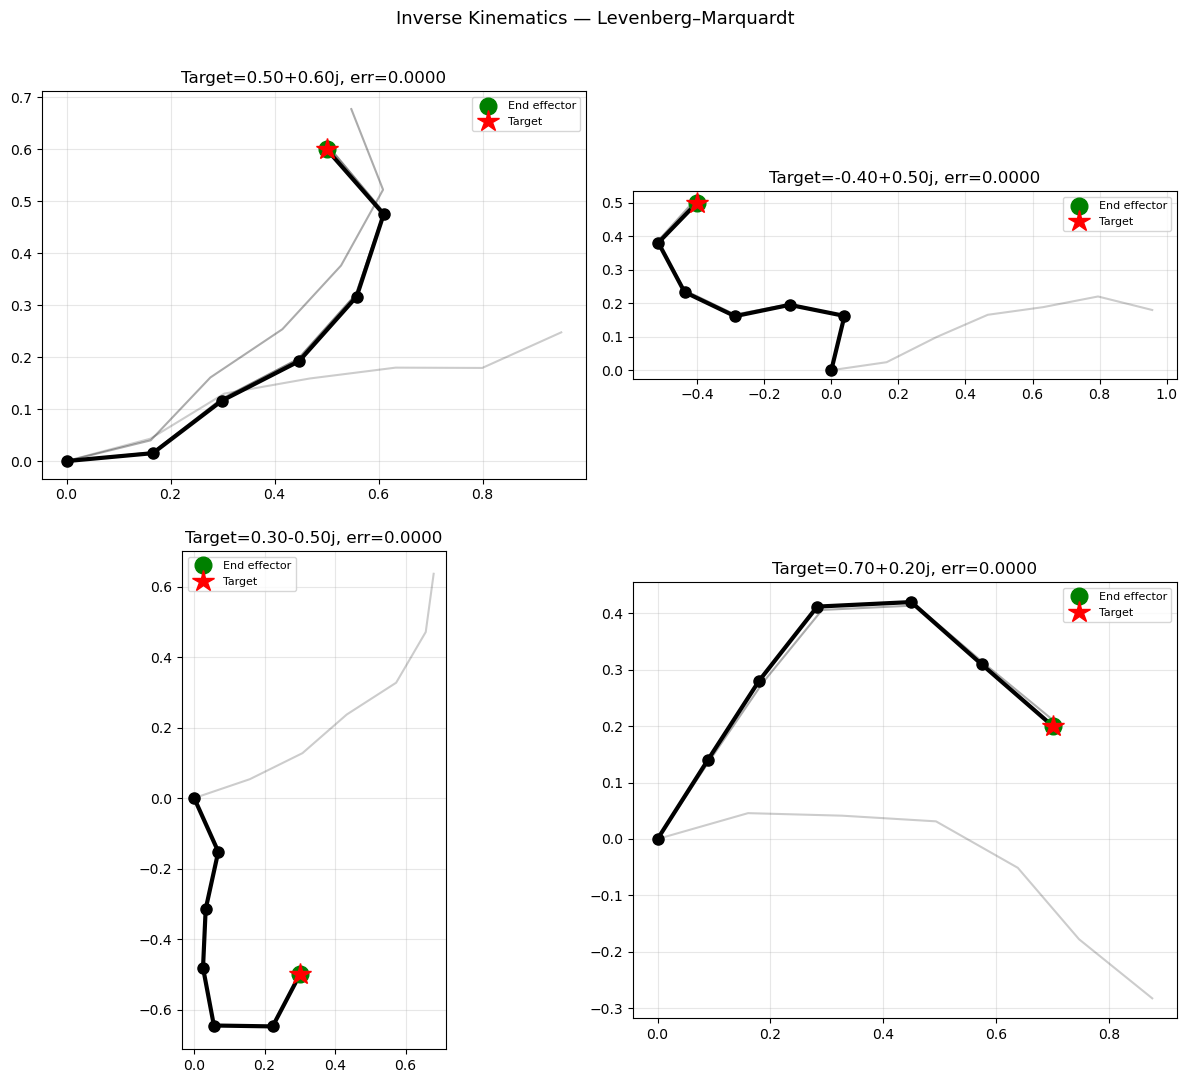

In [4]:
def ik_levenberg_marquardt(r, theta_init, target, n_iter=60, rho=0.3):
    """
    Inverse kinematics via Levenberg-Marquardt.
    Returns trajectory of theta arrays and error list.
    """
    theta = theta_init.copy()
    y = np.array([target.real, target.imag])
    history = [theta.copy()]
    errors = []

    for _ in range(n_iter):
        pos = forward_kinematics(r, theta)
        end = pos[-1]
        residual = np.array([end.real - y[0], end.imag - y[1]])
        errors.append(np.linalg.norm(residual))
        J = jacobian(r, theta)
        # LM step: (J^T J + rho I)^{-1} J^T residual
        A = J.T @ J + rho * np.eye(len(theta))
        grad = J.T @ residual
        theta = theta - np.linalg.solve(A, grad)
        history.append(theta.copy())

    return history, np.array(errors)

# Test with several targets
targets = [0.5 + 0.6j, -0.4 + 0.5j, 0.3 - 0.5j, 0.7 + 0.2j]

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for ax, target in zip(axes.ravel(), targets):
    theta_start = rng.uniform(-0.5, 0.5, n_links)
    history, errors = ik_levenberg_marquardt(r_arm, theta_start, target, n_iter=60)
    pos_final = forward_kinematics(r_arm, history[-1])
    # Show a few intermediate configurations
    for k in range(0, len(history), max(1, len(history)//6)):
        pos_k = forward_kinematics(r_arm, history[k])
        alpha = 0.2 + 0.8 * k / len(history)
        ax.plot(pos_k.real, pos_k.imag, 'k-', lw=1.5, alpha=alpha)
    draw_arm(pos_final, target=target, ax=ax,
             title=f'Target={target:.2f}, err={errors[-1]:.4f}')

plt.suptitle('Inverse Kinematics — Levenberg–Marquardt', fontsize=13)
plt.tight_layout(); plt.savefig('ik_lm.png', dpi=100, bbox_inches='tight'); plt.show()

### Effect of damping parameter $\rho$

The damping $\rho$ controls the trade-off between speed (small $\rho$, Gauss-Newton-like) and stability (large $\rho$, gradient descent-like). We compare convergence curves.

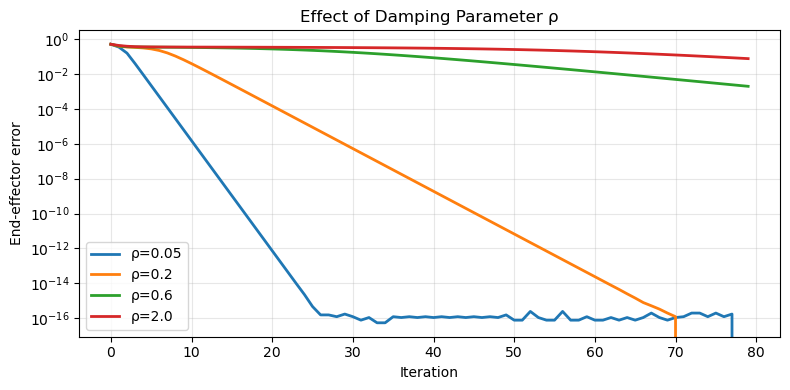

In [5]:
target_test = 0.5 + 0.4j
theta_test = rng.uniform(-0.3, 0.3, n_links)
rho_vals = [0.05, 0.2, 0.6, 2.0]

plt.figure(figsize=(8, 4))
for rho_v in rho_vals:
    _, errs = ik_levenberg_marquardt(r_arm, theta_test.copy(), target_test,
                                      n_iter=80, rho=rho_v)
    plt.semilogy(errs, lw=2, label=f'ρ={rho_v}')

plt.xlabel('Iteration'); plt.ylabel('End-effector error')
plt.title('Effect of Damping Parameter ρ')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('ik_rho.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive: move the target

In [ ]:
def show_ik(target_x=0.5, target_y=0.4, rho=0.3, n_iter=60):
    target_i = target_x + 1j * target_y
    theta_init_i = rng.uniform(-0.5, 0.5, n_links)
    history_i, errors_i = ik_levenberg_marquardt(r_arm, theta_init_i, target_i,
                                                   n_iter=n_iter, rho=rho)
    pos_final_i = forward_kinematics(r_arm, history_i[-1])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for k in range(0, len(history_i), max(1, len(history_i)//8)):
        pos_k = forward_kinematics(r_arm, history_i[k])
        alpha = 0.15 + 0.85 * k / len(history_i)
        axes[0].plot(pos_k.real, pos_k.imag, 'k-', lw=1.5, alpha=alpha)
    draw_arm(pos_final_i, target=target_i, ax=axes[0], title=f'Final err={errors_i[-1]:.5f}')

    axes[1].semilogy(errors_i, 'b-o', ms=3, lw=1.5)
    axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Error')
    axes[1].set_title('Convergence'); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

interact(show_ik,
         target_x=FloatSlider(min=-0.9, max=0.9, step=0.05, value=0.5),
         target_y=FloatSlider(min=-0.9, max=0.9, step=0.05, value=0.4),
         rho=FloatSlider(min=0.01, max=2.0, step=0.05, value=0.3, description='ρ'),
         n_iter=IntSlider(min=10, max=150, step=10, value=60));

### Snippet

In [6]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt

    fig, axes = _plt.subplots(2, 2, figsize=(11, 10))
    for ax, target in zip(axes.ravel(), targets):
        theta_s = np.random.default_rng(int(abs(target.real)*100)).uniform(-0.5, 0.5, n_links)
        history_s, errors_s = ik_levenberg_marquardt(r_arm, theta_s, target, n_iter=60)
        pos_final_s = forward_kinematics(r_arm, history_s[-1])
        for k in range(0, len(history_s), max(1, len(history_s)//6)):
            pos_k = forward_kinematics(r_arm, history_s[k])
            ax.plot(pos_k.real, pos_k.imag, 'k-', lw=1.5, alpha=0.2+0.8*k/len(history_s))
        ax.plot(pos_final_s.real, pos_final_s.imag, 'b-o', lw=2, ms=7)
        ax.plot(pos_final_s[-1].real, pos_final_s[-1].imag, 'go', ms=12)
        ax.plot(target.real, target.imag, 'r*', ms=16)
        ax.set_aspect('equal'); ax.set_title(f'err={errors_s[-1]:.4f}', fontsize=10)
        ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- Forward kinematics is a composition of rotations; the Jacobian has a simple closed form for planar arms.
- **Inverse kinematics** is a nonlinear least-squares problem — generally non-convex with multiple solutions.
- The **Levenberg–Marquardt** method combines Gauss–Newton fast convergence with gradient-descent stability.
- Damping $\rho$ handles **singularities** (when two links are fully extended/contracted) by preventing large steps.

## Bibliography

- K. Levenberg, *A method for the solution of certain problems in least squares*, Quart. Appl. Math. 2, 1944.
- D. Marquardt, *An algorithm for least-squares estimation of nonlinear parameters*, SIAM J. Appl. Math. 11, 1963.
- B. Siciliano et al., *Robotics: Modelling, Planning and Control*, Springer, 2009.